
**======================================================================================================**
<p align="center"><b>|| FUSION GENERAL || PROYECTO ANÁLISIS DE DATOS</b></p>

**======================================================================================================**
**Integrantes:**  
*   Vismark Abner Choque Cachi
*   Elizabeth Cusi Ancasi
  
**Materia: Analisis de Datos**  
**Docente: M.Sc. Madelina Loza Soliz**  
**Sigla: DAT-263**
**======================================================================================================**

## **IMPORTACION DE LOS DATASETS**

In [1]:
import pandas as pd
datos_estudiantes = pd.read_csv("data/modelos/datos_prepro_estudiantes.csv") # este es el tuyo
data_notas = pd.read_csv("data/modelos/datos_prepro_notas.csv")

In [2]:
datos_estudiantes.head()

,dip,Género,Provincia,Ciudad,Colegio,Administración del Colegio,Edad,Provincia_LE,Ciudad_LE,Género_FEMENINO,Género_MASCULINO,Género_NO RESPONDE,Administración del Colegio_CEMA,Administración del Colegio_CONVENIO,Administración del Colegio_FISCAL,Administración del Colegio_OTRO,Administración del Colegio_PRIVADA,Edad_std
0,260910,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16,32,44,0,1,0,0,0,1,0,0,-2.664500
1,487541,MASCULINO,MURILLO,LA PAZ,COL.NAL.TEC.HUM. FRANZ TAMAYO NAAAAAAAAO3,FISCAL,31,32,44,0,1,0,0,0,1,0,0,-0.609555
2,748784,MASCULINO,MURILLO,LA PAZ,DIVINO MAESTRO,PRIVADA,33,32,44,0,1,0,0,0,0,0,1,-0.335562
3,1763419,MASCULINO,MURILLO,LA PAZ,CIE 12 DE OCTUBRE,FISCAL,51,32,44,0,1,0,0,0,1,0,0,2.130373
4,2140504,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16,32,44,0,1,0,0,0,1,0,0,-2.664500


In [3]:
data_notas.head()

,Gestión,C.I.,Nota2T,NotaBIO-99,NotaCOM-99,NotaEST-99,NotaFIS-99,NotaGMT-99,NotaINF-99,NotaLIN-99,...,Carrera_Ciencias Químicas,Carrera_Estadística,Carrera_Física,Carrera_Informática,Carrera_Matemática,Periodo_PRIMERO,Periodo_PRIMERO (2T),Periodo_PRIMERO (PSA),Periodo_SEGUNDO,Periodo_SEGUNDO (PSA)
0,2009,4295732,-1.0,60.0,-1.0,-1.0,67.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0
1,2009,4299485,-1.0,52.0,-1.0,-1.0,51.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0
2,2009,4751856,-1.0,73.0,-1.0,-1.0,55.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0
3,2009,4755839,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0
4,2009,4766488,-1.0,18.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0


## **CORTA DESCRIPCION DEL DATASET**

### **Dataset "DATOS ESTUDIANTES MADE"**

In [4]:

datos_estudiantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   dip                                  1987 non-null   int64  
 1   Género                               1987 non-null   object 
 2   Provincia                            1987 non-null   object 
 3   Ciudad                               1987 non-null   object 
 4   Colegio                              1987 non-null   object 
 5   Administración del Colegio           1987 non-null   object 
 6   Edad                                 1987 non-null   int64  
 7   Provincia_LE                         1987 non-null   int64  
 8   Ciudad_LE                            1987 non-null   int64  
 9   Género_FEMENINO                      1987 non-null   int64  
 10  Género_MASCULINO                     1987 non-null   int64  
 11  Género_NO RESPONDE            

### **Dataset "NOTAS MADE"**

In [5]:
data_notas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5691 entries, 0 to 5690
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gestión                    5691 non-null   int64  
 1   C.I.                       5691 non-null   object 
 2   Nota2T                     5691 non-null   float64
 3   NotaBIO-99                 5691 non-null   float64
 4   NotaCOM-99                 5691 non-null   float64
 5   NotaEST-99                 5691 non-null   float64
 6   NotaFIS-99                 5691 non-null   float64
 7   NotaGMT-99                 5691 non-null   float64
 8   NotaINF-99                 5691 non-null   float64
 9   NotaLIN-99                 5691 non-null   float64
 10  NotaMAT-99                 5691 non-null   float64
 11  NotaPSA                    5691 non-null   float64
 12  NotaQMC-99                 5691 non-null   float64
 13  promedio_aprobacion        5691 non-null   float

**CONVERSION DE DATOS**  
Antes de nada empezar con la fusion de los datasets se hace la conversion de las columnas identificadoras de ambos datasets en un mismo tipo, asi no tener problemas en la fusion

In [6]:
data_notas["C.I."] = data_notas["C.I."].astype(str).str.strip()
datos_estudiantes["dip"] = datos_estudiantes["dip"].astype(str).str.strip()


# **FUSION DE DATASETS**


El siguiente código realiza una **fusión interna** (`INNER JOIN`) entre los dos DataFrames (`datos_estudiantes` y `data_notas`) utilizando los identificadores únicos validados previamente.
## **Componentes de la Fusión**

| Componente | Rol en el DataFrame | Descripción |
| :--- | :--- | :--- |
| **`datos_estudiantes`** | **Izquierda** | Contiene la información demográfica, ubicación y el identificador **`dip`**. |
| **`data_notas`** | **Derecha** | Contiene las notas del examen y el identificador **`C.I.`**. |
| **`left_on="dip"`** | **Clave Izquierda** | La columna **`dip`** de la tabla izquierda se usará para la coincidencia. |
| **`right_on="C.I."`** | **Clave Derecha** | La columna **`C.I.`** de la tabla derecha se usará para la coincidencia. |
| **`how="inner"`** | **Tipo de Unión** | **Fusión Interna (`INNER JOIN`)**. Solo se incluyen las filas donde **`dip` es idéntico a `C.I.`**. |

In [7]:
# Conjuntos únicos
set_notas = set(data_notas["C.I."])
set_dips  = set(datos_estudiantes["dip"])

# Intersección
coinciden_unicos = set_notas & set_dips

print("Cantidad de identificadores únicos que coinciden:", len(coinciden_unicos))


Cantidad de identificadores únicos que coinciden: 351


Se tiene 342 identificadores unicos "C.I." 

In [8]:
fusion = datos_estudiantes.merge(
    data_notas,
    left_on="dip",
    right_on="C.I.",
    how="inner"
)
print("------------------------------------------------")
print("Total de filas fusionadas:", len(fusion))

print("------------------------------------------------")
print(fusion.info())


------------------------------------------------
Total de filas fusionadas: 421
------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   dip                                  421 non-null    object 
 1   Género                               421 non-null    object 
 2   Provincia                            421 non-null    object 
 3   Ciudad                               421 non-null    object 
 4   Colegio                              421 non-null    object 
 5   Administración del Colegio           421 non-null    object 
 6   Edad                                 421 non-null    int64  
 7   Provincia_LE                         421 non-null    int64  
 8   Ciudad_LE                            421 non-null    int64  
 9   Género_FEMENINO                    

Visualizacion de datos

In [9]:
fusion.head(20)

,dip,Género,Provincia,Ciudad,Colegio,Administración del Colegio,Edad,Provincia_LE,Ciudad_LE,Género_FEMENINO,...,Carrera_Ciencias Químicas,Carrera_Estadística,Carrera_Física,Carrera_Informática,Carrera_Matemática,Periodo_PRIMERO,Periodo_PRIMERO (2T),Periodo_PRIMERO (PSA),Periodo_SEGUNDO,Periodo_SEGUNDO (PSA)
0,260910,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16,32,44,0,...,0,0,0,0,0,1,0,0,0,0
1,260910,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16,32,44,0,...,0,0,0,0,0,1,0,0,0,0
2,2318517,MASCULINO,MURILLO,LA PAZ,LIBERTADORES DE AMERICA,FISCAL,52,32,44,0,...,0,0,0,0,0,1,0,0,0,0
3,2379805,NO RESPONDE,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,52,32,44,0,...,0,0,1,0,0,1,0,0,0,0
4,2539628,MASCULINO,MURILLO,LA PAZ,AMERICAN SCHOOL,PRIVADA,51,32,44,0,...,0,0,1,0,0,0,0,0,1,0
5,2539628,MASCULINO,MURILLO,LA PAZ,AMERICAN SCHOOL,PRIVADA,51,32,44,0,...,0,0,1,0,0,1,0,0,0,0
6,2643974,FEMENINO,MURILLO,LA PAZ,LOS PINOS,PRIVADA,44,32,44,1,...,0,0,1,0,0,0,0,0,1,0
7,3324122,FEMENINO,MURILLO,LA PAZ,TEC. MIXTO FABRIL 18 DE MAYO FE Y ALEGRIA,FISCAL,45,32,44,1,...,1,0,0,0,0,0,0,0,1,0
8,3489994,MASCULINO,MURILLO,LA PAZ,INSTITUTO DOMINGO SAVIO,PRIVADA,35,32,44,0,...,0,1,0,0,0,1,0,0,0,0
9,3999799,MASCULINO,SUD CHICHAS,TUPIZA,COLEGIO ACIONAL MIXTO SUIPACHA,FISCAL,35,46,76,0,...,1,0,0,0,0,1,0,0,0,0


In [10]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------------
# 1) Cargar datos
# ---------------------------------------------------------------
df = fusion.copy()


### ELEGIR VARIABLES

### Explicación de la Matriz de Correlación (versión simple y directa)

La matriz de correlación muestra qué tan relacionadas están las variables entre sí.  
Si dos materias tienen una correlación alta, significa que los estudiantes que sacan buena nota en una, normalmente también lo hacen en la otra.

- Valores cercanos a **1.0** → relación fuerte y positiva  
- Valores cercanos a **0.0** → casi no tienen relación  
- Valores negativos → cuando una sube, la otra baja

Los colores ayudan a ver rápido dónde hay relaciones importantes:
- **Rojo fuerte** → materias que están muy conectadas  
- **Azul fuerte** → relación inversa  
- **Claro** → poca relación

Los números dentro de cada cuadro justifican la interpretación porque muestran exactamente **qué tan fuerte es** cada relación, permitiendo identificar:
- Qué materias se parecen más en el tipo de habilidad que miden  
- Qué variables aportan al *promedio_de_aprobación*  
- Si hay variables que prácticamente no influyen

Esta matriz es útil porque permite decidir qué variables son realmente relevantes para los modelos y cuáles no aportan información significativa.


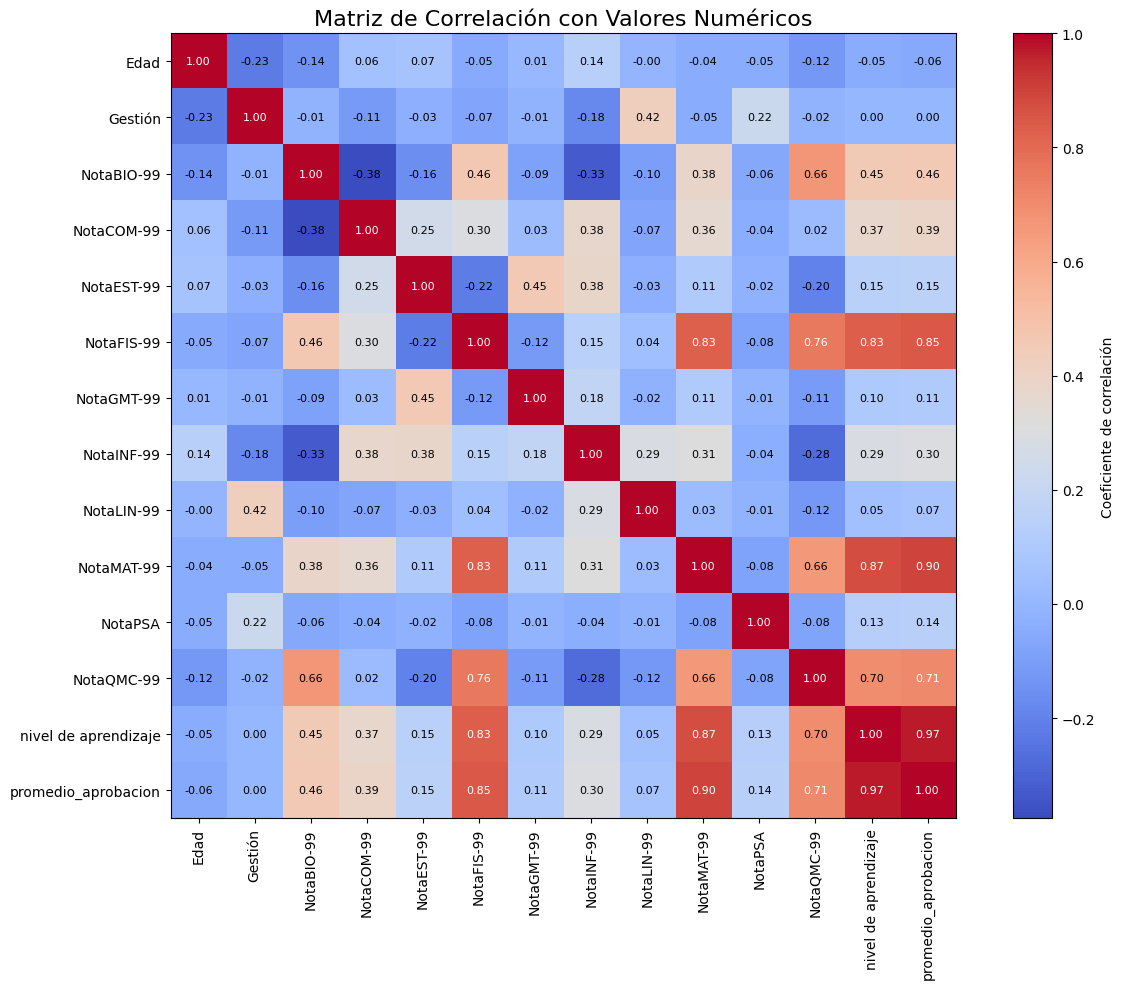

In [11]:
# ================================================================
# MATRIZ DE CORRELACIÓN CUADRADA CON NÚMEROS (Colab / VSCode)
# ================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Lista de variables
variables = [
    "Edad", "Gestión",
    "NotaBIO-99", "NotaCOM-99", "NotaEST-99",
    "NotaFIS-99", "NotaGMT-99", "NotaINF-99",
    "NotaLIN-99", "NotaMAT-99", "NotaPSA",
    "NotaQMC-99", "nivel de aprendizaje",
    "promedio_aprobacion"
]

# Seleccionar solo columnas existentes para evitar errores
vars_existentes = [v for v in variables if v in df.columns]

if len(vars_existentes) < 2:
    raise ValueError("No hay suficientes columnas válidas para calcular correlación.")

# Calcular matriz de correlación
corr = df[vars_existentes].corr()

# Gráfico
plt.figure(figsize=(13, 10))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Coeficiente de correlación")
plt.title("Matriz de Correlación con Valores Numéricos", fontsize=16)

# Etiquetas
plt.xticks(ticks=np.arange(len(vars_existentes)), labels=vars_existentes, rotation=90)
plt.yticks(ticks=np.arange(len(vars_existentes)), labels=vars_existentes)

#  Colocar valores numéricos en cada celda
for i in range(len(vars_existentes)):
    for j in range(len(vars_existentes)):
        valor = corr.iloc[i, j]
        plt.text(
            j, i,                           # ubicación x, y
            f"{valor:.2f}",                 # formato de número
            ha="center", va="center",       # alineación
            color="black" if abs(valor) < 0.7 else "white",  # contraste automático
            fontsize=8
        )

plt.tight_layout()
plt.show()



### Análisis de Importancia de Variables – Explicación Simple

En este análisis se evaluó qué variables influyen más en el *promedio de aprobación* usando dos métodos:

## 1) Correlación lineal (Pearson)
La correlación lineal mide qué tan directamente sube o baja el promedio cuando cambia una variable.  
Valores cercanos a **1 o -1** indican relación fuerte, y valores cerca de **0** muestran poca conexión.

Este análisis sirve para ver relaciones **simples y directas**, pero solo detecta efectos lineales.

## 2) Importancia no lineal (Gradient Boosting)
El modelo Gradient Boosting identifica la importancia real de cada variable considerando relaciones:
- no lineales,
- combinadas,
- interacciones entre materias.

Es una medida más completa porque el modelo aprende patrones complejos que la correlación no detecta.

##  ¿Por qué se usan ambos métodos?
- La **correlación** justifica si una variable tiene relación directa con el promedio.
- El **Gradient Boosting** revela si una variable es útil para predecir, incluso aunque su correlación sea baja.
  
En otras palabras:
- **Pearson dice qué tan relacionada está una materia.**
- **Gradient Boosting dice si realmente sirve para predecir.**

##  ¿Qué concluye este análisis?
- Las materias con mayor correlación y mayor importancia en GB son las que mejor explican el rendimiento académico.
- Si una variable tiene baja correlación pero alta importancia, significa que aporta información útil de manera no lineal.
- Si aparece baja en ambos métodos, su aporte al modelo es mínimo.
- tambien la eliminacion del nivel de aprendizaje por demasiada correlacion superando el 0.90

Estudiantes totales con datos completos: 421

1) CORRELACIÓN LINEAL CON EL PROMEDIO
  Variable      r  p-value
      Edad -0.056    0.252
   Gestión  0.004    0.927
NotaBIO-99  0.456    0.000
NotaCOM-99  0.391    0.000
NotaEST-99  0.152    0.002
NotaFIS-99  0.846    0.000
NotaGMT-99  0.109    0.026
NotaINF-99  0.301    0.000
NotaLIN-99  0.066    0.173
NotaMAT-99  0.896    0.000
   NotaPSA  0.143    0.003
NotaQMC-99  0.708    0.000


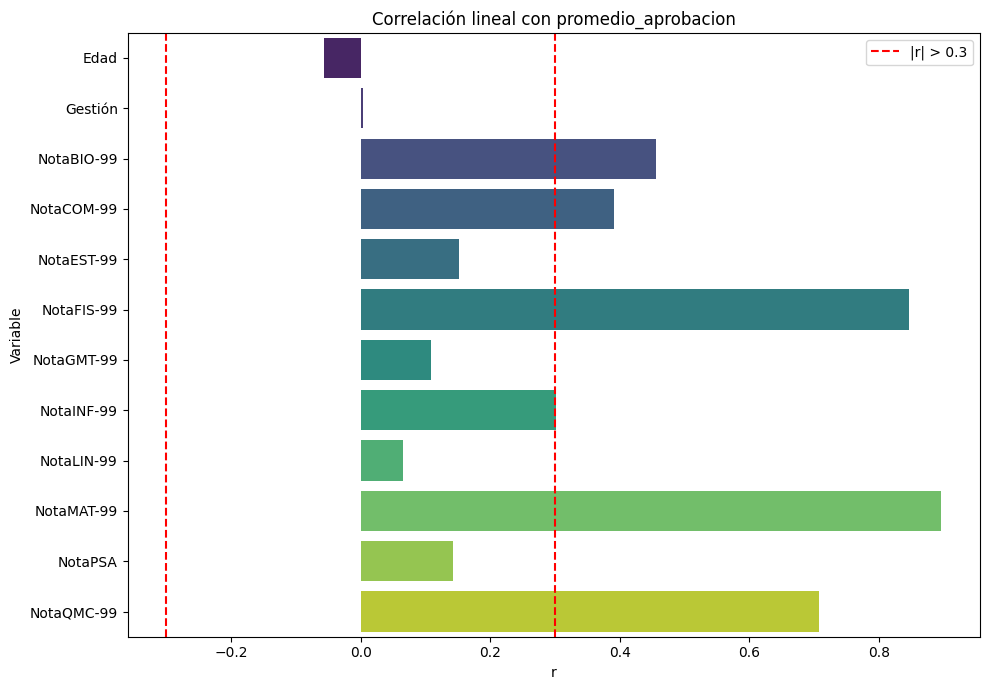

In [12]:
# ===============================================================
# ANÁLISIS DE IMPORTANCIA DE VARIABLES – 100% FUNCIONANDO (13 variables)
# ===============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------
# 1) TUS 13 VARIABLES REALES
# ---------------------------------------------------------------
features = ["Edad", "Gestión",
    "NotaBIO-99", "NotaCOM-99", "NotaEST-99",
    "NotaFIS-99", "NotaGMT-99", "NotaINF-99",
    "NotaLIN-99", "NotaMAT-99", "NotaPSA",
    "NotaQMC-99"]
target = "promedio_aprobacion"

df_raw = df[features + [target]].dropna().reset_index(drop=True)
print(f"Estudiantes totales con datos completos: {len(df_raw)}\n")

X = df_raw[features]
y = df_raw[target]

# ---------------------------------------------------------------
# 2) CORRELACIÓN LINEAL (Pearson)
# ---------------------------------------------------------------
print("1) CORRELACIÓN LINEAL CON EL PROMEDIO")
correlaciones = []
for col in features:
    r, p = pearsonr(df_raw[col], y)
    correlaciones.append({"Variable": col, "r": r, "p-value": p})

corr_df = pd.DataFrame(correlaciones).round(3)
print(corr_df.to_string(index=False))

plt.figure(figsize=(10,7))
sns.barplot(data=corr_df, x="r", y="Variable", palette="viridis")
plt.title("Correlación lineal con promedio_aprobacion")
plt.axvline(0.3, color='red', linestyle='--', label="|r| > 0.3")
plt.axvline(-0.3, color='red', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()



2) IMPORTANCIA NO LINEAL – Gradient Boosting
  Variable  Importancia (%)
NotaMAT-99            80.44
NotaFIS-99             8.86
NotaQMC-99             4.21
NotaEST-99             1.74
NotaBIO-99             1.28
NotaCOM-99             1.26
   NotaPSA             0.82
NotaINF-99             0.67
   Gestión             0.52
NotaLIN-99             0.15
      Edad             0.03
NotaGMT-99             0.03


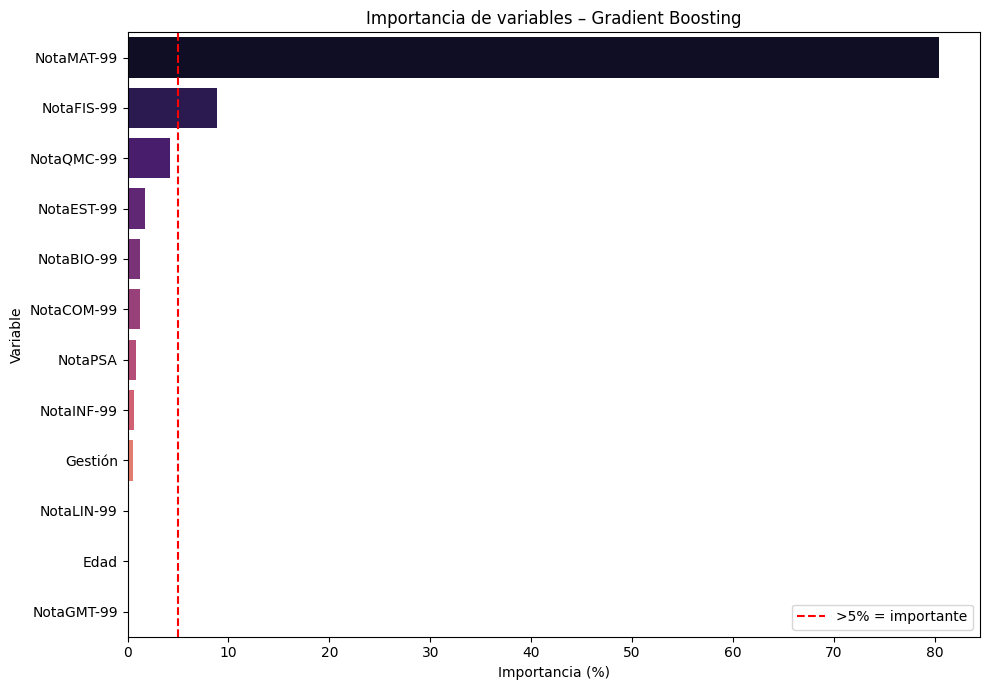

In [13]:

# ---------------------------------------------------------------
# 3) IMPORTANCIA GRADIENT BOOSTING (no lineal)
# ---------------------------------------------------------------
print("\n2) IMPORTANCIA NO LINEAL – Gradient Boosting")
gb = GradientBoostingRegressor(n_estimators=1200, random_state=42)
gb.fit(X, y)

imp_gb = pd.DataFrame({
    "Variable": features,
    "Importancia (%)": np.round(gb.feature_importances_ * 100, 2)
}).sort_values("Importancia (%)", ascending=False).reset_index(drop=True)

print(imp_gb.to_string(index=False))

plt.figure(figsize=(10,7))
sns.barplot(data=imp_gb, x="Importancia (%)", y="Variable", palette="magma")
plt.title("Importancia de variables – Gradient Boosting")
plt.axvline(5, color='red', linestyle='--', label=">5% = importante")
plt.legend()
plt.tight_layout()
plt.show()




###  Comparación de 3 Modelos Predictivos – Explicación Simple

Se entrenaron tres modelos para predecir el *promedio de aprobación* usando las cinco materias base (Física, Matemáticas, Química, Biología y Comunicación).  
El objetivo es identificar qué modelo predice mejor el rendimiento académico.

###  Modelos utilizados

1. **Ridge Regression**
   - Modelo lineal.
   - Funciona bien cuando la relación entre las notas y el promedio es básicamente lineal.
   - Utiliza normalización para evitar que una materia influya más por tener rangos numéricos distintos.

2. **Árbol de Decisión**
   - Modelo no lineal.
   - Aprende reglas tipo “si la nota en matemáticas es alta, entonces…”.
   - Tiende a sobreajustar si no se controla su profundidad (aquí está limitado para evitar errores).

3. **Gradient Boosting (MEJOR)**
   - Es un ensamble avanzado de muchos árboles pequeños.
   - Aprende patrones complejos y relaciones no lineales.
   - Normalmente supera a los otros dos modelos porque combina múltiples correcciones sucesivas.

**Método de entrenamiento utilizado**
- Para garantizar una evaluación justa, los datos se dividieron en:
- 80% para entrenamiento (train)
- 20% para prueba (test)
- Semilla fija: random_state = 42 para asegurar reproducibilidad.
- Este procedimiento permite medir qué tan bien generaliza cada modelo a nuevo

###  Métricas evaluadas

- **MSE:** error promedio cuadrado (entre menor, mejor).  
- **RMSE:** error promedio interpretado en la misma escala que el promedio.  
- **R²:** qué tanto explica el modelo (entre 0 y 1; más cerca de 1 es mejor).

### Interpretación de los resultados

- **Gradient Boosting obtiene el mejor desempeño**, porque puede captar relaciones complejas entre las notas.
- **Ridge** tiene buen rendimiento, pero está limitado a relaciones lineales simples.
- **Árbol de Decisión** funciona, pero su precisión es menor porque un solo árbol no capta toda la estructura de los datos.

###  Conclusión general
Gradient Boosting es el modelo más adecuado para predecir el promedio de aprobación de los estudiantes universitarios porque:
- maneja relaciones no lineales,
- combina muchos árboles para reducir errores,
- y logra el mejor equilibrio entre error bajo y capacidad predictiva alta.


Hiperparámetros de cada modelo
1) Ridge Regression
alpha = 100.0
random_state = 42
2) Árbol de Decisión
max_depth = 8
min_samples_leaf = 10
random_state = 42
3) Gradient Boosting (MEJOR)
n_estimators = 1200
learning_rate = 0.04
max_depth = 6
subsample = 0.8
min_samples_leaf = 10
random_state = 42

In [14]:
# ===============================================================
# 3 MODELOS UNIVERSIDAD BOLIVIA 
# ===============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import ipywidgets as widgets          # ← aquí está bien
from IPython.display import display, clear_output
import joblib

# ---------------------------------------------------------------
# 1) DATOS
# ---------------------------------------------------------------
features = [ 'NotaFIS-99', 'NotaMAT-99', 'NotaQMC-99', 'NotaBIO-99', 'NotaCOM-99']
target = "promedio_aprobacion"

df_model = df[features + [target]].dropna().reset_index(drop=True)
print(f"Estudiantes universitarios usados: {len(df_model)}")

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------------
# 2) Scaler solo para Ridge
# ---------------------------------------------------------------
scaler = StandardScaler()
X_train_ridge = scaler.fit_transform(X_train)
X_test_ridge  = scaler.transform(X_test)

# ---------------------------------------------------------------
# 3) LOS 3 MODELOS
# ---------------------------------------------------------------
modelos = {
    "Ridge Regression": Ridge(alpha=100.0, random_state=42),
    "Árbol de Decisión": DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42),
    "Gradient Boosting (MEJOR)": GradientBoostingRegressor(
        n_estimators=1200, learning_rate=0.04, max_depth=6,
        subsample=0.8, min_samples_leaf=10, random_state=42
    )
}

# ---------------------------------------------------------------
# 4) RESULTADOS CON MSE
# ---------------------------------------------------------------
print("\n" + "═"*90)
print("        RESULTADOS DE LOS 3 MODELOS - UNIVERSIDAD BOLIVIA")
print("═"*90)
print(f"{'Modelo':<28} {'MSE':>10} {'RMSE':>10} {'R²':>12}")
print("-"*90)

for nombre, modelo in modelos.items():
    if nombre == "Ridge Regression":
        modelo.fit(X_train_ridge, y_train)
        pred = modelo.predict(X_test_ridge)
    else:
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
    
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    
    print(f"{nombre:<28} {mse:10.2f} {rmse:10.2f} {r2:11.4f}")

print("═"*90)


Estudiantes universitarios usados: 421

══════════════════════════════════════════════════════════════════════════════════════════
        RESULTADOS DE LOS 3 MODELOS - UNIVERSIDAD BOLIVIA
══════════════════════════════════════════════════════════════════════════════════════════
Modelo                              MSE       RMSE           R²
------------------------------------------------------------------------------------------
Ridge Regression                  55.15       7.43      0.9111
Árbol de Decisión                 45.94       6.78      0.9260
Gradient Boosting (MEJOR)         15.42       3.93      0.9752
══════════════════════════════════════════════════════════════════════════════════════════


# AJUSTE DE HIPERPARAMETROS


In [ ]:
# ============================================================
# 1) IMPORTACIONES
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# ============================================================
# 2) DATOS
# ============================================================
features = ['NotaFIS-99', 'NotaMAT-99', 'NotaQMC-99', 'NotaBIO-99', 'NotaCOM-99']
target = "promedio_aprobacion"

df_model = df[features + [target]].dropna().reset_index(drop=True)
print(f"Estudiantes universitarios usados: {len(df_model)}")

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 3) GRID SEARCH PARA GRADIENT BOOSTING
# ============================================================

param_grid = {
    "n_estimators": [300, 600, 900, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.  1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.6, 0.8, 1.0],
    "min_samples_leaf": [2, 5, 10]
}

gb = GradientBoostingRegressor(random_state=42)

grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("\nBuscando mejores hiperparámetros...")
grid.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(grid.best_params_)

best_gb = grid.best_estimator_

# ============================================================
# 4) EVALUACIÓN FINAL
# ============================================================
pred = best_gb.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("\n════════ RESULTADOS FINALES (BOOSTING OPTIMIZADO) ════════")
print(f"MSE:   {mse:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"R²:    {r2:.4f}")
print("══════════════════════════════════════════════════════════")

# ============================================================
# 5) GUARDAR MEJOR MODELO
# ============================================================
joblib.dump(best_gb, "best_gradient_boosting.pkl")
print("\nModelo guardado como best_gradient_boosting.pkl")


Estudiantes universitarios usados: 421

Buscando mejores hiperparámetros...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

Mejores hiperparámetros encontrados:
{'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 1200, 'subsample': 0.6}

════════ RESULTADOS FINALES (BOOSTING OPTIMIZADO) ════════
MSE:   11.0602
RMSE:  3.3257
R²:    0.9822
══════════════════════════════════════════════════════════

Modelo guardado como best_gradient_boosting.pkl


Este código obtiene la importancia de cada variable usada por el modelo Gradient Boosting para predecir el promedio de aprobación. La importancia muestra qué materias influyen más en el modelo. Luego ordena esos valores y genera un gráfico de barras para visualizar fácilmente cuáles notas tienen mayor peso en la predicción.

Este código grafica los valores reales del promedio de aprobación contra los valores predichos por el modelo Gradient Boosting. El scatter muestra qué tan cerca están las predicciones de la línea ideal (donde predicción = valor real). Mientras más se alinean los puntos a esa línea, mejor es el rendimiento del modelo, permitiendo evaluar visualmente su precisión.

Modelo encontrado: Gradient Boosting (MEJOR)


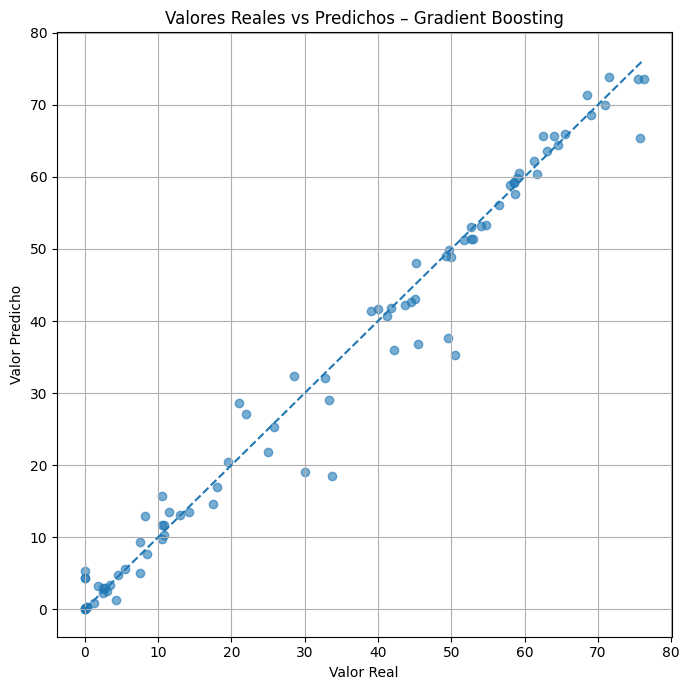

In [17]:
# ===============================================================
# 6) GRÁFICO: Valores Reales vs Predichos (Gradient Boosting)
# ===============================================================
import matplotlib.pyplot as plt

# Buscar automáticamente el modelo Gradient Boosting
gb_model = None
for nombre, modelo in modelos.items():
    if isinstance(modelo, GradientBoostingRegressor):
        gb_model = modelo
        print(f"Modelo encontrado: {nombre}")
        break

if gb_model is None:
    raise Exception(" No existe un modelo GradientBoostingRegressor en 'modelos'.")

# Obtener predicciones del conjunto de prueba
y_pred = gb_model.predict(X_test)

# -----------------------------
# GRÁFICO REAL vs PREDICHO
# -----------------------------
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         linestyle='--')

plt.xlabel("Valor Real")
plt.ylabel("Valor Predicho")
plt.title("Valores Reales vs Predichos – Gradient Boosting")
plt.grid(True)
plt.tight_layout()
plt.show()


### PREDICCION

In [18]:

# ---------------------------------------------------------------
# 5) WIDGET CORREGIDO (la única línea que fallaba)
# ---------------------------------------------------------------
print("\nPREDICTOR DE PROMEDIO UNIVERSITARIO - BOLIVIA\n")

sliders = {}
for f in features:
    if f == "Edad":
        sliders[f] = widgets.IntSlider(          # ← aquí estaba el error: era "Widgets"
            value=21, min=17, max=40, step=1, description="Edad:", 
            style={'description_width': 'initial'}
        )
    else:
        sliders[f] = widgets.IntSlider(
            value=70, min=0, max=100, step=1, 
            description=f"{f}:", style={'description_width': 'initial'}
        )

dropdown = widgets.Dropdown(options=list(modelos.keys()), value="Gradient Boosting (MEJOR)", description="Modelo:")
boton = widgets.Button(description="PREDECIR PROMEDIO FINAL", button_style="success", icon="graduation-cap")
salida = widgets.Output()

def predecir(b):
    with salida:
        clear_output()
        valores = [sliders[f].value for f in features]
        entrada = np.array([valores])
        
        modelo = modelos[dropdown.value]
        if dropdown.value == "Ridge Regression":
            pred = modelo.predict(scaler.transform(entrada))[0]
        else:
            pred = modelo.predict(entrada)[0]
        
        print("UNIVERSIDAD BOLIVIANA - PREDICCIÓN")
        print("═" * 60)
        print(f"   PROMEDIO → {pred:.2f}/100")
        print("═" * 60)
        for f, v in zip(features, valores):
            print(f"   • {f:15}: {v}" + (" años" if f=="Edad" else "/100"))
        print("─" * 60)
        if    pred >= 51: print("APROBADO ")
        else:            print("REPROBADO")
        print("─" * 60)

boton.on_click(predecir)

display(widgets.HTML("<h2>PREDICTOR UNIVERSITARIO BOLIVIA</h2>"))
display(dropdown)
display(widgets.VBox(list(sliders.values())))
display(boton)
display(salida)



PREDICTOR DE PROMEDIO UNIVERSITARIO - BOLIVIA



HTML(value='<h2>PREDICTOR UNIVERSITARIO BOLIVIA</h2>')

Dropdown(description='Modelo:', index=2, options=('Ridge Regression', 'Árbol de Decisión', 'Gradient Boosting …

Button(button_style='success', description='PREDECIR PROMEDIO FINAL', icon='graduation-cap', style=ButtonStyle…

Output()

# FUSION 2

In [18]:

datos_examen = pd.read_csv("data/modelos/datos_prepro_examen_respuestas.csv")


In [19]:
datos_examen.head()

,Escriba su edad en años cumplidos,Genero al que pertenece,Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?,¿Porqué?,Que plataforma utiliza para sus clases virtuales,Cuales son los medios de comunicación que utiliza para comunicarse con el docente:,Cantidad de materias que ha tomado hasta la fecha,Cantidad de materias aprobadas hasta la fecha,Las razones por la que aprobó sus materias son:,Cantidad de materias reprobadas hasta la fecha.,...,En las sesiones on line de clases utiliza_Jitsi Meet,En las sesiones on line de clases utiliza_Meet de Google,"En las sesiones on line de clases utiliza_Meet de Google, Jitsi Meet",En las sesiones on line de clases utiliza_Teams,En las sesiones on line de clases utiliza_Zoom Meet,"En las sesiones on line de clases utiliza_Zoom Meet, Jitsi Meet","En las sesiones on line de clases utiliza_Zoom Meet, Meet de Google","En las sesiones on line de clases utiliza_Zoom Meet, Meet de Google, Jitsi Meet","En las sesiones on line de clases utiliza_Zoom Meet, Meet de Google, Jitsi Meet, Teams","En las sesiones on line de clases utiliza_Zoom Meet, Meet de Google, Teams"
0,55,Masculino,3,0.272827,0.001100,0.001100,40.0,50,0.125413,60.0,...,1,0,0,0,0,0,0,0,0,0
1,24,Masculino,3,0.311331,0.597360,0.271727,13.0,42,0.012101,5.0,...,0,0,0,0,0,0,1,0,0,0
2,20,Masculino,1,0.311331,0.326733,0.225523,10.0,2,0.125413,16.0,...,0,1,0,0,0,0,0,0,0,0
3,18,Masculino,2,0.311331,0.597360,0.193619,7.0,0,0.246425,0.0,...,0,1,0,0,0,0,0,0,0,0
4,24,Masculino,1,0.311331,0.326733,0.271727,13.0,1,0.246425,6.0,...,0,0,0,0,0,0,1,0,0,0


In [20]:
datos_examen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 39 columns):
 #   Column                                                                                                                                                   Non-Null Count  Dtype  
---  ------                                                                                                                                                   --------------  -----  
 0   Escriba su edad en años cumplidos                                                                                                                        909 non-null    int64  
 1   Genero al que pertenece                                                                                                                                  909 non-null    object 
 2   Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?  909 non-n

# **FUSION DE DATASETS**


El siguiente código realiza una **fusión interna** (`INNER JOIN`) entre los dos DataFrames (`datos_estudiantes` y `data_notas`) utilizando los identificadores únicos validados previamente.

## **Componentes de fusion**

Antes de la fusión, es esencial entender los valores únicos en las columnas clave de ambos *DataFrames* para prever problemas de formato, codificación o discrepancias que podrían afectar cualquier análisis bivariado posterior.

| Variable | DataFrame Base (`fusion_1` - Datos Pre-Fusionados) | DataFrame Encuesta (`datos_examen` - Encuesta) | Estado de los Datos |
| :--- | :--- | :--- | :--- |
| **Género** | **`fusion_1["Género"]`** | **`datos_examen["Genero al que pertenece"]`** | Los formatos de texto deben coincidir para agrupar (ej. 'MASCULINO' vs 'Masculino'). |
| **Edad** | **`fusion_1["Edad"]`** | **`datos_examen["Escriba su edad en años cumplidos"]`** | Se debe asegurar que los valores de `datos_examen` sean numéricos e iguales para comparar con la `Edad` calculada en `fusion_1`. |
| **Nivel de Aprendizaje** | **`fusion_1["nivel de aprendizaje"]`** | **`datos_examen["El nivel de aprendizaje que ha logrado fue..."]`** | Ambos están en una escala 1-5, lo que permite la comparación directa. |


In [21]:
# =====================================================================================================
print(fusion["Género"].unique())

print(fusion["Edad"].unique())

print(fusion["nivel de aprendizaje"].unique())


# =====================================================================================================
print(datos_examen["Genero al que pertenece"].unique())

print(datos_examen["Escriba su edad en años cumplidos"].unique())

print(datos_examen["El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):"].dtype)



['MASCULINO' 'NO RESPONDE' 'FEMENINO']
[16 52 51 44 45 35 46 32 30 41 36 34 33 50 31 48 47 37 29 43 38 42 28 39
 40 27]
[1 2 4 3 5]
['Masculino' 'Femenino']
[55 24 20 18 23 28 21 17 19 33 29 25 22 26 37 12 27 31 46 35 36 32 34 39
 30 41 54 44 48 40 38 43 47]
int64


In [22]:
fusion["Género"] = (
    fusion["Género"]
    .astype(str)
    .str.strip()
    .str.upper()
)

datos_examen["Genero al que pertenece"] = (
    datos_examen["Genero al que pertenece"]
    .astype(str)
    .str.strip()
    .str.upper()
)


In [23]:
print(fusion["Género"].unique())
print(datos_examen["Genero al que pertenece"].unique())


['MASCULINO' 'NO RESPONDE' 'FEMENINO']
['MASCULINO' 'FEMENINO']


In [24]:
fusion["Edad"] = (
    fusion["Edad"]
    .astype(float)
    .astype("Int64")
)

datos_examen["Escriba su edad en años cumplidos"] = (
    datos_examen["Escriba su edad en años cumplidos"]
    .astype(float)
    .astype("Int64")
)


In [25]:
print(fusion["Edad"].unique())
print(datos_examen["Escriba su edad en años cumplidos"].unique())

<IntegerArray>
[16, 52, 51, 44, 45, 35, 46, 32, 30, 41, 36, 34, 33, 50, 31, 48, 47, 37, 29,
 43, 38, 42, 28, 39, 40, 27]
Length: 26, dtype: Int64
<IntegerArray>
[55, 24, 20, 18, 23, 28, 21, 17, 19, 33, 29, 25, 22, 26, 37, 12, 27, 31, 46,
 35, 36, 32, 34, 39, 30, 41, 54, 44, 48, 40, 38, 43, 47]
Length: 33, dtype: Int64


In [26]:
fusion["nivel de aprendizaje"] = (
    fusion["nivel de aprendizaje"]
    .astype(float)
    .astype("Int64")
)

datos_examen["El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):"] = (
    datos_examen["El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):"]
    .astype(float)
    .astype("Int64")
)


In [27]:
print(fusion["nivel de aprendizaje"].unique())

print(datos_examen["El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):"].unique())


<IntegerArray>
[1, 2, 4, 3, 5]
Length: 5, dtype: Int64
<IntegerArray>
[3, 5, 2, 1, 4]
Length: 5, dtype: Int64


In [28]:
fusion["ID_TEMP"] = (
    fusion["Género"].astype(str)
    + "_" +
    fusion["Edad"].astype(str)
    + "_" +
    fusion["nivel de aprendizaje"].astype(str)
)

datos_examen["ID_TEMP"] = (
    datos_examen["Genero al que pertenece"].astype(str)
    + "_" +
    datos_examen["Escriba su edad en años cumplidos"].astype(str)
    + "_" +
    datos_examen["El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):"].astype(str)
)


In [29]:
grupo_fusion = (
    fusion
    .groupby(["Género", "Edad", "nivel de aprendizaje"])
    .size()
    .reset_index(name="cantidad_fusion")
)

grupo_examen = (
    datos_examen
    .groupby([
        "Genero al que pertenece",
        "Escriba su edad en años cumplidos",
        "El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):"
    ])
    .size()
    .reset_index(name="cantidad_examen")
)


In [30]:
for _, fila in grupo_fusion.iterrows():
    print(
        f"GÉNERO: {fila['Género']} | "
        f"EDAD: {fila['Edad']} | "
        f"NIVEL: {fila['nivel de aprendizaje']}  ==  "
        f"{fila['cantidad_fusion']} registros en fusion_1"
    )


GÉNERO: FEMENINO | EDAD: 16 | NIVEL: 1  ==  3 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 16 | NIVEL: 2  ==  3 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 16 | NIVEL: 3  ==  2 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 27 | NIVEL: 2  ==  1 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 28 | NIVEL: 1  ==  1 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 28 | NIVEL: 3  ==  4 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 28 | NIVEL: 4  ==  1 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 29 | NIVEL: 3  ==  2 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 29 | NIVEL: 4  ==  1 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 30 | NIVEL: 1  ==  7 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 30 | NIVEL: 2  ==  5 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 30 | NIVEL: 3  ==  7 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 30 | NIVEL: 4  ==  2 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 31 | NIVEL: 1  ==  5 registros en fusion_1
GÉNERO: FEMENINO | EDAD: 31 | NIVEL: 2  ==  3 re

In [31]:
for _, fila in grupo_examen.iterrows():
    print(
        f"GÉNERO: {fila['Genero al que pertenece']} | "
        f"EDAD: {fila['Escriba su edad en años cumplidos']} | "
        f"NIVEL: {fila['El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):']}  ==  "
        f"{fila['cantidad_examen']} registros en examen"
    )

GÉNERO: FEMENINO | EDAD: 12 | NIVEL: 3  ==  1 registros en examen
GÉNERO: FEMENINO | EDAD: 17 | NIVEL: 2  ==  3 registros en examen
GÉNERO: FEMENINO | EDAD: 17 | NIVEL: 3  ==  10 registros en examen
GÉNERO: FEMENINO | EDAD: 17 | NIVEL: 4  ==  4 registros en examen
GÉNERO: FEMENINO | EDAD: 18 | NIVEL: 1  ==  2 registros en examen
GÉNERO: FEMENINO | EDAD: 18 | NIVEL: 2  ==  6 registros en examen
GÉNERO: FEMENINO | EDAD: 18 | NIVEL: 3  ==  19 registros en examen
GÉNERO: FEMENINO | EDAD: 18 | NIVEL: 4  ==  11 registros en examen
GÉNERO: FEMENINO | EDAD: 19 | NIVEL: 1  ==  2 registros en examen
GÉNERO: FEMENINO | EDAD: 19 | NIVEL: 2  ==  6 registros en examen
GÉNERO: FEMENINO | EDAD: 19 | NIVEL: 3  ==  21 registros en examen
GÉNERO: FEMENINO | EDAD: 19 | NIVEL: 4  ==  11 registros en examen
GÉNERO: FEMENINO | EDAD: 20 | NIVEL: 2  ==  4 registros en examen
GÉNERO: FEMENINO | EDAD: 20 | NIVEL: 3  ==  28 registros en examen
GÉNERO: FEMENINO | EDAD: 20 | NIVEL: 4  ==  16 registros en examen
GÉN

In [32]:
set_fusion  = set(fusion["ID_TEMP"])
set_examen  = set(datos_examen["ID_TEMP"])

coinciden_unicos = set_fusion & set_examen

print("Cantidad de coincidencias exactas:", len(coinciden_unicos))


Cantidad de coincidencias exactas: 46


In [33]:
datos_examen_ren = datos_examen.rename(columns={
    "Genero al que pertenece": "Género",
    "Escriba su edad en años cumplidos": "Edad",
    "El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):": "nivel de aprendizaje"
})


In [34]:
fusion = fusion.merge(
    datos_examen_ren,
    on=["Género", "Edad", "nivel de aprendizaje"],
    how="inner"
)


In [35]:
print("------------------------------------------------")
print("Total de filas fusionadas:", len(fusion))

print("------------------------------------------------")
print(fusion.info())


------------------------------------------------
Total de filas fusionadas: 276
------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 83 columns):
 #   Column                                                                                                                                                   Non-Null Count  Dtype  
---  ------                                                                                                                                                   --------------  -----  
 0   dip                                                                                                                                                      276 non-null    object 
 1   Género                                                                                                                                                   276 non-null    object 
 2   Provincia                        

In [36]:
len(fusion)   # → 255 filas

276

In [37]:
# modelos de clasificacion
# Cantidad de columnas por tipo de dato
fusion.dtypes.value_counts()


int64      52
float64    20
object      9
Int64       2
Name: count, dtype: int64

In [38]:
# Mostrar columnas que son de tipo object
object_cols = fusion.select_dtypes(include=['object']).columns
print(object_cols)


Index(['dip', 'Género', 'Provincia', 'Ciudad', 'Colegio',
       'Administración del Colegio', 'C.I.', 'ID_TEMP_x', 'ID_TEMP_y'],
      dtype='object')


# MODELOS DE CLASIFICACION

# MODELO DE CLASIFICACION RANDOM FOREST


     MÉTRICAS RANDOM FOREST
Exactitud (Accuracy): 0.9529

  REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        59
           1       0.92      0.92      0.92        26

    accuracy                           0.95        85
   macro avg       0.94      0.94      0.94        85
weighted avg       0.95      0.95      0.95        85



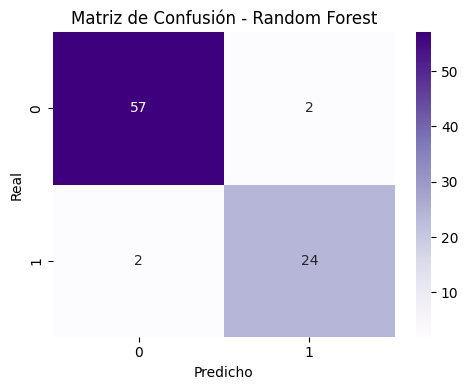


IMPORTANCIA DE VARIABLES
                              Variable  Importancia
21                          NotaMAT-99     0.261072
17                          NotaFIS-99     0.169922
23                          NotaQMC-99     0.163187
14                          NotaBIO-99     0.055854
15                          NotaCOM-99     0.045199
19                          NotaINF-99     0.041326
11                            Edad_std     0.021023
0                                 Edad     0.017451
12                             Gestión     0.014722
16                          NotaEST-99     0.011457
27                      Carrera_Física     0.007678
2                            Ciudad_LE     0.006331
30                     Periodo_PRIMERO     0.005823
18                          NotaGMT-99     0.005286
28                 Carrera_Informática     0.005212
33                     Periodo_SEGUNDO     0.005101
4                     Género_MASCULINO     0.004953
1                         Provincia_LE

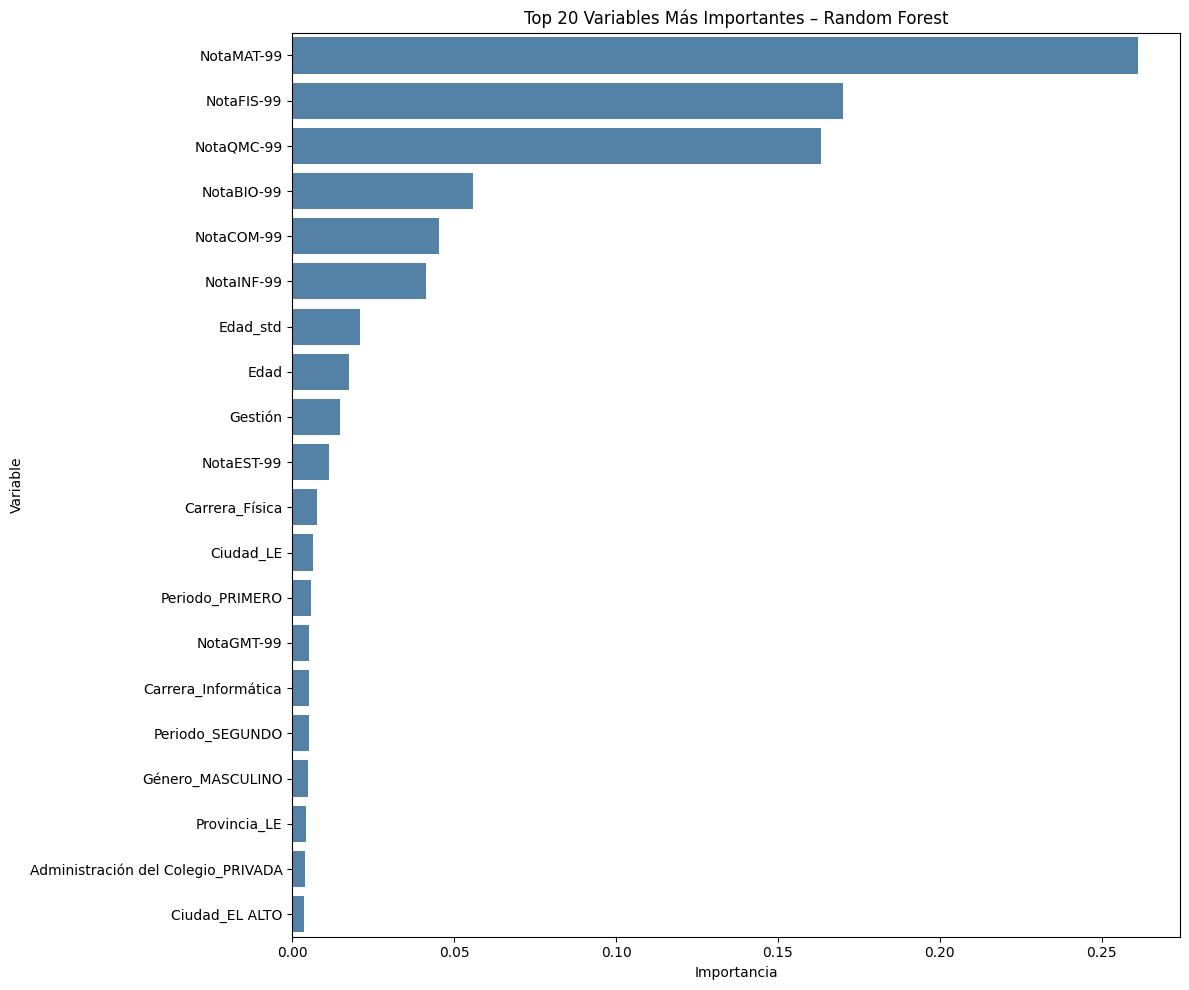

In [36]:
# ===============================================================
# RANDOM FOREST – MÉTRICAS + IMPORTANCIA DE VARIABLES + MATRIZ DE CONFUSIÓN
# ===============================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 0. PREPARAR DATOS ---
df = fusion.copy()
cols_to_drop = ["dip", "C.I.", "ID_TEMP_x", "ID_TEMP_y",
                "promedio_aprobacion", "nivel de aprendizaje"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Codificar automáticamente columnas object (excepto "Género al que pertenece")
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = [c for c in cat_cols if c != "Género al que pertenece"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)

# --- 1. VARIABLES ---
X = df.drop(columns=["Estado"])
y = df["Estado"]

# --- 2. DIVISIÓN ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. MODELO RANDOM FOREST ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- 4. PREDICCIONES ---
y_pred_rf = rf_model.predict(X_test)

# --- 5. MÉTRICAS ---
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print("\n====================")
print("     MÉTRICAS RANDOM FOREST")
print("====================")
print(f"Exactitud (Accuracy): {accuracy_rf:.4f}")

print("\n====================")
print("  REPORTE DE CLASIFICACIÓN")
print("====================")
print(report_rf)

# --- 6. MATRIZ DE CONFUSIÓN GRÁFICA ---
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# --- 7. GUARDAR MÉTRICAS PARA TABLA COMPARATIVA ---
metrics_rf = classification_report(y_test, y_pred_rf, output_dict=True)
metrics_rf_dict = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": metrics_rf['weighted avg']['precision'],
    "Recall": metrics_rf['weighted avg']['recall'],
    "F1-Score": metrics_rf['weighted avg']['f1-score'],
    "Soporte": int(np.sum([metrics_rf[c]['support'] for c in metrics_rf if c not in ('accuracy','macro avg','weighted avg')]))
}

# --- 8. IMPORTANCIA DE VARIABLES ---
importances = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("\n==============================")
print("IMPORTANCIA DE VARIABLES")
print("==============================")
print(importances.head(20))

# --- 9. GRÁFICO DE IMPORTANCIA (UN SOLO COLOR) ---
plt.figure(figsize=(12, 10))
top20 = importances.head(20)
sns.barplot(
    x="Importancia",
    y="Variable",
    data=top20,
    color="steelblue"
)
plt.title("Top 20 Variables Más Importantes – Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()




# **XGBClassifier**


     MÉTRICAS
Exactitud (Accuracy): 0.9765

  REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        59
           1       1.00      0.92      0.96        26

    accuracy                           0.98        85
   macro avg       0.98      0.96      0.97        85
weighted avg       0.98      0.98      0.98        85



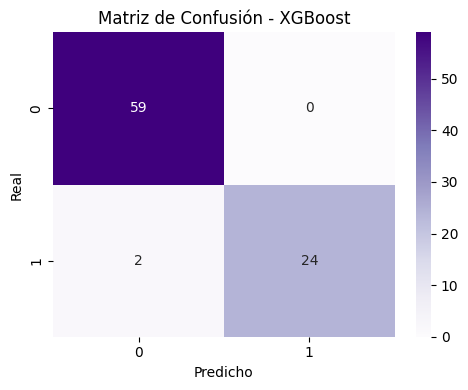


IMPORTANCIA DE VARIABLES
                               Variable  Importancia
21                           NotaMAT-99     0.526704
16                           NotaEST-99     0.084800
28                  Carrera_Informática     0.047980
17                           NotaFIS-99     0.038338
19                           NotaINF-99     0.029704
12                              Gestión     0.023693
74                        Ciudad_LA PAZ     0.023188
23                           NotaQMC-99     0.021867
4                      Género_MASCULINO     0.018958
2                             Ciudad_LE     0.018292
15                           NotaCOM-99     0.018215
14                           NotaBIO-99     0.017930
247                 Colegio_SAN CALIXTO     0.017359
27                       Carrera_Física     0.016139
72                       Ciudad_EL ALTO     0.014689
33                      Periodo_SEGUNDO     0.013644
0                                  Edad     0.012399
10   Administración 

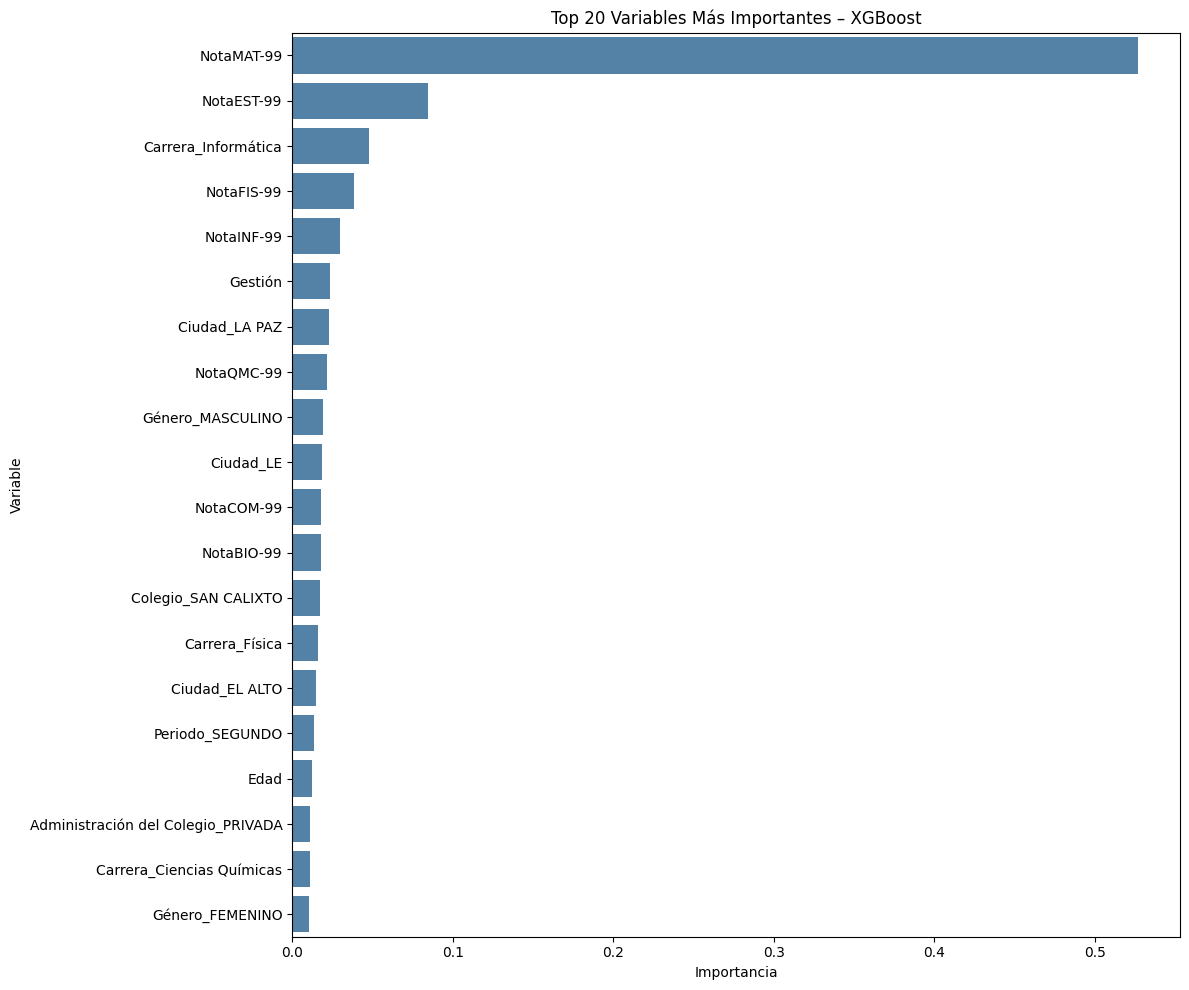


Primeras 10 predicciones del conjunto de prueba:
   Real  Predicho  Probabilidad
0     0         0      0.000208
1     0         0      0.000379
2     0         0      0.000285
3     0         0      0.000228
4     0         0      0.000217
5     0         0      0.000380
6     1         1      0.860798
7     0         0      0.000133
8     0         0      0.000331
9     0         0      0.000185


In [43]:
# ===============================================================
# XGBOOST – MÉTRICAS + IMPORTANCIA DE VARIABLES + MATRIZ DE CONFUSIÓN
# ===============================================================

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0. PREPARAR DATOS ---
df = fusion.copy()
cols_to_drop = ["dip", "C.I.", "ID_TEMP_x", "ID_TEMP_y", 
                "promedio_aprobacion", "nivel de aprendizaje"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df = df.dropna()

# Detectar columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns

# Codificar dummies
if len(cat_cols) > 0:
    dummies = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)
    df = df.drop(columns=cat_cols)
    df = pd.concat([df, dummies], axis=1)

df = df.loc[:, ~df.columns.duplicated()]  # eliminar duplicados

# --- 1. VARIABLES ---
X = df.drop(columns=["Estado"])
y = df["Estado"]

# --- 2. DIVISIÓN EN ENTRENAMIENTO Y PRUEBA ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. MODELO XGBOOST ---
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)
xgb.fit(X_train, y_train)

# --- 4. PREDICCIÓN ---
y_pred = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

# --- 5. MÉTRICAS ---
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\n====================")
print("     MÉTRICAS")
print("====================")
print(f"Exactitud (Accuracy): {accuracy:.4f}")

print("\n====================")
print("  REPORTE DE CLASIFICACIÓN")
print("====================")
print(report)

# --- 6. MATRIZ DE CONFUSIÓN GRÁFICA ---
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Matriz de Confusión - XGBoost")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# --- 7. EXTRAER MÉTRICAS PARA TABLA COMPARATIVA ---
metrics_xgb = classification_report(y_test, y_pred, output_dict=True)
metrics_xgb_dict = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": metrics_xgb['weighted avg']['precision'],
    "Recall": metrics_xgb['weighted avg']['recall'],
    "F1-Score": metrics_xgb['weighted avg']['f1-score'],
    "Soporte": int(np.sum([metrics_xgb[c]['support'] for c in metrics_xgb if c not in ('accuracy','macro avg','weighted avg')]))
}

# --- 8. IMPORTANCIA DE VARIABLES ---
importances = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": xgb.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("\n==============================")
print("IMPORTANCIA DE VARIABLES")
print("==============================")
print(importances.head(20))

# --- 9. GRÁFICO DE IMPORTANCIA (UN SOLO COLOR) ---
plt.figure(figsize=(12, 10))
top20 = importances.head(20)
sns.barplot(
    x="Importancia",
    y="Variable",
    data=top20,
    color="steelblue"
)
plt.title("Top 20 Variables Más Importantes – XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# --- 10. PREDICCIONES CON PROBABILIDADES ---
test_results_xgb = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred,
    "Probabilidad": y_pred_proba
})

print("\nPrimeras 10 predicciones del conjunto de prueba:")
print(test_results_xgb.head(10))



Usando dispositivo: cpu

     MÉTRICAS
Exactitud (Accuracy): 0.9176

  MATRIZ DE CONFUSIÓN
[[55  4]
 [ 3 23]]

 REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        59
           1       0.85      0.88      0.87        26

    accuracy                           0.92        85
   macro avg       0.90      0.91      0.90        85
weighted avg       0.92      0.92      0.92        85



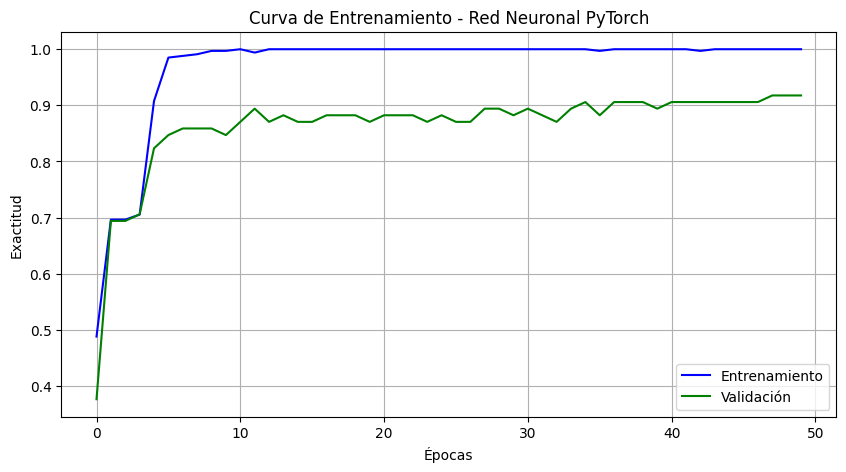


Primeras 10 predicciones:
   Real  Predicho  Probabilidad
0     0         0  1.022653e-07
1     0         0  6.716148e-07
2     0         0  7.923141e-08
3     0         0  8.340495e-11
4     0         0  4.507329e-07
5     0         0  1.720579e-09
6     1         0  7.860269e-05
7     0         0  1.668204e-11
8     0         0  2.479401e-10
9     0         0  1.184253e-10


In [31]:
# ===============================================================
# RED NEURONAL PyTorch – MÉTRICAS + CURVA DE ENTRENAMIENTO + TABLA
# ===============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# 0. DISPOSITIVO
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# =============================
# 1. PREPROCESAMIENTO
# =============================
df = fusion.copy()

cols_to_drop = ["dip", "C.I.", "ID_TEMP_x", "ID_TEMP_y",
                "promedio_aprobacion", "nivel de aprendizaje"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df = df.dropna()

gender_col = "Género al que pertenece" if "Género al que pertenece" in df.columns else None
cat_cols = df.select_dtypes(include=['object']).columns
if gender_col in cat_cols:
    cat_cols = [c for c in cat_cols if c != gender_col]

if len(cat_cols) > 0:
    df_encoded = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)
    df = df.drop(columns=cat_cols)
    df = pd.concat([df, df_encoded], axis=1)

df = df.loc[:, ~df.columns.duplicated()]

# Variables
X = df.drop(columns=["Estado"])
y = df["Estado"]
if y.dtype == 'object':
    y = y.astype('category').cat.codes

# Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tensores
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).to(device)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# =============================
# 2. MODELO
# =============================
class NeuralNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = NeuralNet(X_train.shape[1]).to(device)

# =============================
# 3. ENTRENAMIENTO
# =============================
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history_acc = []
history_val_acc = []

EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    # Evaluación por época
    model.eval()
    with torch.no_grad():
        train_pred = (model(X_train_tensor).squeeze() >= 0.5).float()
        val_pred = (model(X_test_tensor).squeeze() >= 0.5).float()

        train_acc = accuracy_score(y_train, train_pred.cpu())
        val_acc = accuracy_score(y_test, val_pred.cpu())

        history_acc.append(train_acc)
        history_val_acc.append(val_acc)

# =============================
# 4. EVALUACIÓN FINAL
# =============================
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_tensor).squeeze().cpu().numpy()
    y_pred = (y_pred_proba >= 0.5).astype(int)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True)

metrics_nn_dict = {
    "Modelo": "Red Neuronal PyTorch",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": report_dict['weighted avg']['precision'],
    "Recall": report_dict['weighted avg']['recall'],
    "F1-Score": report_dict['weighted avg']['f1-score'],
    "Soporte": report_dict['weighted avg']['support']  # ya es float
}

print("\n====================")
print("     MÉTRICAS")
print("====================")
print(f"Exactitud (Accuracy): {accuracy:.4f}")

print("\n====================")
print("  MATRIZ DE CONFUSIÓN")
print("====================")
print(cm)

print("\n====================")
print(" REPORTE DE CLASIFICACIÓN")
print(classification_report(y_test, y_pred))

# =============================
# 5. CURVA DE ENTRENAMIENTO
# =============================
plt.figure(figsize=(10,5))
plt.plot(history_acc, label="Entrenamiento", color="blue")
plt.plot(history_val_acc, label="Validación", color="green")
plt.xlabel("Épocas")
plt.ylabel("Exactitud")
plt.title("Curva de Entrenamiento - Red Neuronal PyTorch")
plt.legend()
plt.grid(True)
plt.show()

# =============================
# 6. PREDICCIONES
# =============================
test_results = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred,
    "Probabilidad": y_pred_proba
})

print("\nPrimeras 10 predicciones:")
print(test_results.head(10))




# AJUSTE DE HIPERPARAMETROS


Mejores hiperparámetros encontrados:
{'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.9}

     MÉTRICAS XGBOOST MEJORADO
Exactitud (Accuracy): 0.9765

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        59
           1       1.00      0.92      0.96        26

    accuracy                           0.98        85
   macro avg       0.98      0.96      0.97        85
weighted avg       0.98      0.98      0.98        85



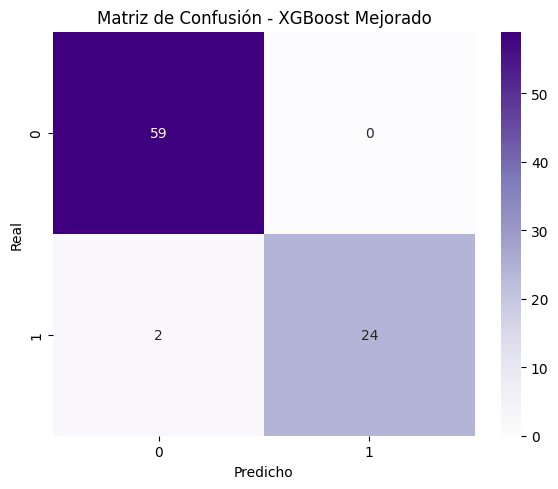


IMPORTANCIA DE VARIABLES
                               Variable  Importancia
21                           NotaMAT-99     0.517945
16                           NotaEST-99     0.103941
17                           NotaFIS-99     0.054865
28                  Carrera_Informática     0.038442
19                           NotaINF-99     0.028716
23                           NotaQMC-99     0.025214
12                              Gestión     0.024397
4                      Género_MASCULINO     0.021799
72                       Ciudad_EL ALTO     0.017739
2                             Ciudad_LE     0.017612
14                           NotaBIO-99     0.016959
33                      Periodo_SEGUNDO     0.016188
3                       Género_FEMENINO     0.013910
15                           NotaCOM-99     0.013555
30                      Periodo_PRIMERO     0.013168
27                       Carrera_Física     0.011660
20                           NotaLIN-99     0.011629
247                 

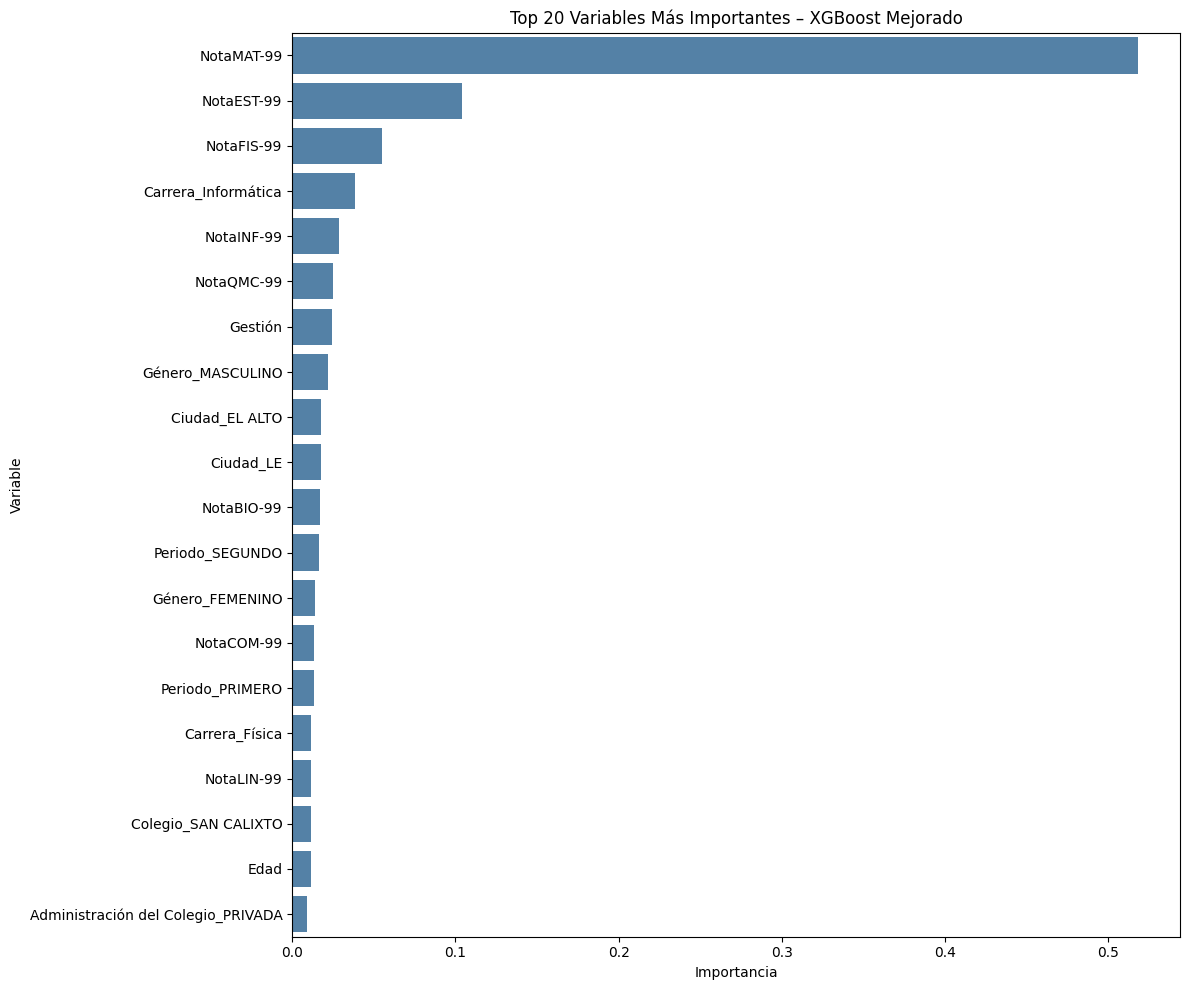


Primeras 10 predicciones del conjunto de prueba:
   Real  Predicho  Probabilidad
0     0         0      0.000186
1     0         0      0.000388
2     0         0      0.000291
3     0         0      0.000219
4     0         0      0.000223
5     0         0      0.000424
6     1         1      0.859173
7     0         0      0.000126
8     0         0      0.000271
9     0         0      0.000183


In [45]:
# ===============================================================
# XGBOOST – MEJORADO + MÉTRICAS + IMPORTANCIA + MATRIZ
# ===============================================================

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0. PREPARAR DATOS ---
df = fusion.copy()
cols_to_drop = ["dip", "C.I.", "ID_TEMP_x", "ID_TEMP_y", 
                "promedio_aprobacion", "nivel de aprendizaje"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df = df.dropna()

# Detectar columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns

# Codificar dummies
if len(cat_cols) > 0:
    dummies = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)
    df = df.drop(columns=cat_cols)
    df = pd.concat([df, dummies], axis=1)

df = df.loc[:, ~df.columns.duplicated()]  # eliminar duplicados

# --- 1. VARIABLES ---
X = df.drop(columns=["Estado"])
y = df["Estado"]

# --- 2. DIVISIÓN ENTRENAMIENTO/PRUEBA ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. XGBOOST CON GRIDSEARCH PARA MEJORES HIPERPARÁMETROS ---
param_grid = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_

print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# --- 4. PREDICCIONES ---
y_pred = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

# --- 5. MÉTRICAS ---
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n====================")
print("     MÉTRICAS XGBOOST MEJORADO")
print("====================")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print("\nReporte de clasificación:\n", report)

# --- 6. MATRIZ DE CONFUSIÓN GRÁFICA ---
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title("Matriz de Confusión - XGBoost Mejorado")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# --- 7. GUARDAR MÉTRICAS PARA TABLA COMPARATIVA ---
metrics_xgb_dict = {
    "Accuracy": accuracy,
    "Precision": classification_report(y_test, y_pred, output_dict=True)['weighted avg']['precision'],
    "Recall": classification_report(y_test, y_pred, output_dict=True)['weighted avg']['recall'],
    "F1-Score": classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score'],
    "Soporte": int(np.sum([classification_report(y_test, y_pred, output_dict=True)[c]['support'] 
                            for c in classification_report(y_test, y_pred, output_dict=True) 
                            if c not in ('accuracy','macro avg','weighted avg')]))
}

# --- 8. IMPORTANCIA DE VARIABLES ---
importances = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": best_xgb.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("\n==============================")
print("IMPORTANCIA DE VARIABLES")
print("==============================")
print(importances.head(20))

# --- 9. GRÁFICO DE IMPORTANCIA ---
plt.figure(figsize=(12, 10))
top20 = importances.head(20)
sns.barplot(
    x="Importancia",
    y="Variable",
    data=top20,
    color="steelblue"
)
plt.title("Top 20 Variables Más Importantes – XGBoost Mejorado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# --- 10. PREDICCIONES CON PROBABILIDADES ---
test_results_xgb = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred,
    "Probabilidad": y_pred_proba
})

print("\nPrimeras 10 predicciones del conjunto de prueba:")
print(test_results_xgb.head(10))

